# Predicting Assessment Scores

## Initial Setup

In [2]:
import os, shutil, time, warnings
import numpy as np
import pandas as pd
import kagglehub

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing, pipelines, validation, baselines
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")


/home/bohdan/code/ai/ai-hw1-predicting-assessment-scores/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_DIR = './data'

if not os.path.exists(DATA_DIR) or not os.listdir(DATA_DIR):
    print("Downloading dataset via kagglehub...")
    cache_path = kagglehub.competition_download('predicting-assessment-scores-hw1-ucu-ai-2026')
    print(f"Files cached at: {cache_path}")
    
    print(f"Copying dataset to {DATA_DIR}")
    shutil.copytree(cache_path, DATA_DIR, dirs_exist_ok=True)
    print("Data ready!")
else:
    print(f"Data already exists in {DATA_DIR}.")

print("Available files:", os.listdir(DATA_DIR))

Data already exists in ./data.
Available files: ['train.csv', 'test.csv', 'README.md', 'data_dictionary.csv', 'sample_submission.csv', 'unlabeled.csv']


In [4]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
unlabeled_df = pd.read_csv(os.path.join(DATA_DIR, 'unlabeled.csv'))

### Elaluation helpers

In [5]:
RANDOM_SEED = 42
N_SPLITS = 5

cv_splitter = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

In [6]:
def evaluate_model(model, X, y, cv, verbose=True):
    """
    Evaluates a scikit-learn compatible model or pipeline using cross-validation.
    
    Parameters:
    - model: scikit-learn estimator or Pipeline
    - X: pandas DataFrame (preferred, keeps column names) or numpy array of features
    - y: pandas Series or numpy array of the target variable
    - cv: scikit-learn cross-validation splitter (e.g., KFold)
    - verbose: print per-fold and summary RMSE if True
    
    Returns:
    - dict containing OOF predictions and computed RMSE metrics
    """
    oof_predictions = np.zeros(len(X))
    fold_rmses = []
    train_rmses = []
    fit_times = []

    y_arr = np.asarray(y)

    if verbose:
        print(f"Evaluating {model.__class__.__name__}...")

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y_arr)):
        if hasattr(X, 'iloc'):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        else:
            X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]
        
        fold_model = clone(model)

        start = time.perf_counter()
        fold_model.fit(X_train, y_train)
        fit_times.append(time.perf_counter() - start)

        val_preds = fold_model.predict(X_val)
        train_rmses.append(np.sqrt(mean_squared_error(y_train, fold_model.predict(X_train))))

        oof_predictions[val_idx] = val_preds

        fold_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
        fold_rmses.append(fold_rmse)
        if verbose:
            print(f"  Fold {fold + 1} RMSE: {fold_rmse:.4f}")

    mean_rmse = np.mean(fold_rmses)
    std_rmse = np.std(fold_rmses)
    overall_rmse = np.sqrt(mean_squared_error(y_arr, oof_predictions))
    mean_train_rmse = np.mean(train_rmses)

    if verbose:
        print("-" * 40)
        print(f"Mean Fold RMSE:   {mean_rmse:.4f} ± {std_rmse:.4f}")
        print(f"Overall OOF RMSE: {overall_rmse:.4f}")
        print(f"Mean train RMSE:  {mean_train_rmse:.4f}")
        print(f"Total fit time:   {sum(fit_times):.1f} s")
        print("-" * 40)

    return {
        'oof_predictions': oof_predictions,
        'fold_rmses': fold_rmses,
        'mean_rmse': mean_rmse,
        'std_rmse': std_rmse,
        'overall_rmse': overall_rmse,
        'mean_train_rmse': mean_train_rmse,
        'fit_time': sum(fit_times)
    }

In [7]:
results = {}   # model name: output of evaluate_model

def results_table(results):
    """Summary of fold-RMSE statistics and OOF RMSE for all evaluated models."""
    return pd.DataFrame({
        name: {'mean fold RMSE': r['mean_rmse'], 'std fold RMSE': r['std_rmse'], 'OOF RMSE': r['overall_rmse'],
                'train RMSE': r.get('mean_train_rmse', np.nan),
               'fit time (s)': r.get('fit_time', np.nan)}
        for name, r in results.items()
    }).T.round(4)

In [10]:
TARGET = 'assessment_score'
NUM_COLS = ['learner_age', 'study_time', 'attendance_rate', 'sleep_duration',
            'study_minutes', 'engagement_index', 'intake_marker']
CAT_COLS = ['gender_group', 'program_track', 'home_internet', 'rest_quality',
            'learning_routine', 'campus_resources', 'assessment_level', 'registration_group']
FEATURES = NUM_COLS + CAT_COLS

## 1. Data Understanding (EDA)

<a id="sec-1-1"></a>
### 1.1 Dataset overview

In [8]:
print(f"Train shape:      {train_df.shape}")
print(f"Test shape:       {test_df.shape}")
print(f"Unlabeled shape:  {unlabeled_df.shape}")

train_df.head()

Train shape:      (441000, 17)
Test shape:       (189000, 16)
Unlabeled shape:  (270000, 16)


,record_id,learner_age,gender_group,program_track,study_time,attendance_rate,home_internet,sleep_duration,rest_quality,learning_routine,campus_resources,assessment_level,study_minutes,engagement_index,intake_marker,registration_group,assessment_score
0,1572288,18.0,other,b.com,0.78,97.8,no,5.15,poor,mixed,low,moderate,43.9,70.74,0.743351,G06,48.5
1,1065516,21.0,other,b.tech,1.65,77.3,yes,6.41,poor,mixed,high,moderate,99.0,55.89,0.971166,G08,50.0
2,1480349,20.0,other,diploma,3.29,61.2,no,8.77,poor,self-study,low,easy,200.5,53.53,0.764103,G11,53.0
3,1128337,24.0,male,diploma,5.33,66.9,no,6.42,good,coaching,medium,moderate,332.0,67.67,0.865821,G10,89.9
4,1794604,23.0,female,bca,6.68,69.3,no,5.63,average,self-study,medium,easy,410.7,75.14,0.223452,G02,91.8


In [9]:
data_dict = pd.read_csv(os.path.join(DATA_DIR, 'data_dictionary.csv')).set_index('column')

feature_types = pd.DataFrame({
    'dtype': train_df.dtypes.astype(str),
    'role': data_dict['type'],
    'example values': train_df.apply(lambda s: ', '.join(map(str, s.dropna().unique()[:3]))),
}).loc[['record_id'] + FEATURES + [TARGET]]
feature_types

,dtype,role,example values
record_id,int64,identifier,"1572288, 1065516, 1480349"
learner_age,float64,numeric,"18.0, 21.0, 20.0"
study_time,float64,numeric,"0.78, 1.65, 3.29"
attendance_rate,float64,numeric,"97.8, 77.3, 61.2"
sleep_duration,float64,numeric,"5.15, 6.41, 8.77"
study_minutes,float64,numeric,"43.9, 99.0, 200.5"
engagement_index,float64,numeric,"70.74, 55.89, 53.53"
intake_marker,float64,numeric,"0.743351, 0.971166, 0.764103"
gender_group,str,categorical,"other, male, female"
program_track,str,categorical,"b.com, b.tech, diploma"


In [10]:
# Integrity checks
print(f"Duplicate record_id in train:        {train_df['record_id'].duplicated().sum()}")
print(f"Fully duplicated feature rows:       {train_df[FEATURES].duplicated().sum()}")
print(f"record_id overlap train/test:        {len(set(train_df['record_id']) & set(test_df['record_id']))}")

Duplicate record_id in train:        0
Fully duplicated feature rows:       0
record_id overlap train/test:        0


<a id="sec-1-2"></a>
### 1.2 Missing values

In [11]:
print(f"Rows with at least one missing value: {train_df[FEATURES].isna().any(axis=1).mean():.1%}")

missing = pd.DataFrame({
    'train %': train_df[FEATURES].isna().mean() * 100,
    'test %': test_df[FEATURES].isna().mean() * 100,
    'unlabeled %': unlabeled_df[FEATURES].isna().mean() * 100,
}).round(2)
missing

Rows with at least one missing value: 31.5%


,train %,test %,unlabeled %
learner_age,2.99,3.11,3.04
study_time,3.22,3.26,3.19
attendance_rate,3.00,3.03,2.96
sleep_duration,2.99,3.03,2.94
study_minutes,2.98,2.94,3.04
engagement_index,3.03,3.10,3.01
intake_marker,2.96,3.06,3.00
gender_group,2.01,2.04,2.00
program_track,2.03,2.09,2.03
home_internet,2.00,1.99,1.95


In [12]:
rows = []
for c in FEATURES:
    m = train_df[c].isna()
    rows.append({'feature': c,
                 'mean target (missing)': train_df.loc[m, TARGET].mean(),
                 'mean target (present)': train_df.loc[~m, TARGET].mean()})
miss_vs_target = pd.DataFrame(rows).set_index('feature')
miss_vs_target['diff'] = miss_vs_target.iloc[:, 0] - miss_vs_target.iloc[:, 1]
miss_vs_target.round(2)

,mean target (missing),mean target (present),diff
feature,,,
learner_age,62.27,62.52,-0.25
study_time,62.41,62.51,-0.10
attendance_rate,62.58,62.51,0.08
sleep_duration,62.36,62.51,-0.16
study_minutes,62.38,62.51,-0.13
engagement_index,62.47,62.51,-0.04
intake_marker,62.30,62.51,-0.21
gender_group,62.47,62.51,-0.04
program_track,62.74,62.50,0.24


<a id="sec-1-3"></a>
### 1.3 Target distribution

count    441000.00
mean         62.51
std          18.92
min          19.60
25%          48.80
50%          62.60
75%          76.30
max         100.00


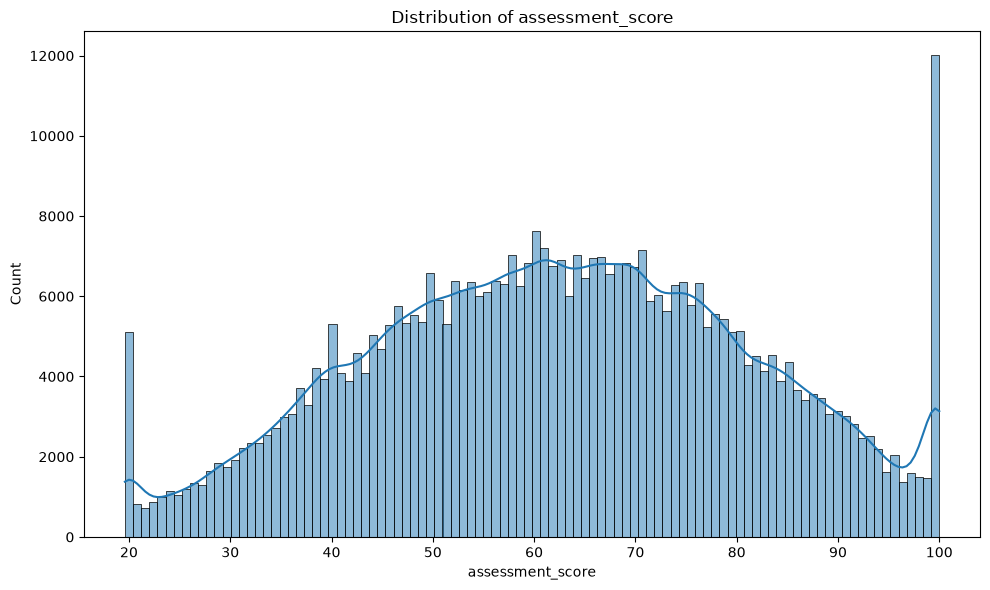

In [13]:
y = train_df[TARGET]
print(y.describe().round(2).to_string())

plt.figure(figsize=(10, 6))
sns.histplot(y, bins=100, kde=True)
plt.title('Distribution of assessment_score')
plt.tight_layout()
plt.show()

<a id="sec-1-4"></a>
### 1.4 Categorical features: inconsistent formatting

In [14]:
# Raw levels vs levels after normalising whitespace and case
rows = []
for c in CAT_COLS:
    raw = train_df[c]
    rows.append({'feature': c,
                 'unique (raw)': raw.nunique(),
                 'unique (normalised)': raw.str.strip().str.lower().nunique(),
                 'rows with padded whitespace': int((raw.notna() & (raw != raw.str.strip())).sum())})
pd.DataFrame(rows).set_index('feature')

,unique (raw),unique (normalised),rows with padded whitespace
feature,,,
gender_group,3,3,0
program_track,14,7,6482
home_internet,2,2,0
rest_quality,6,3,6511
learning_routine,10,5,6635
campus_resources,3,3,0
assessment_level,3,3,0
registration_group,12,12,0


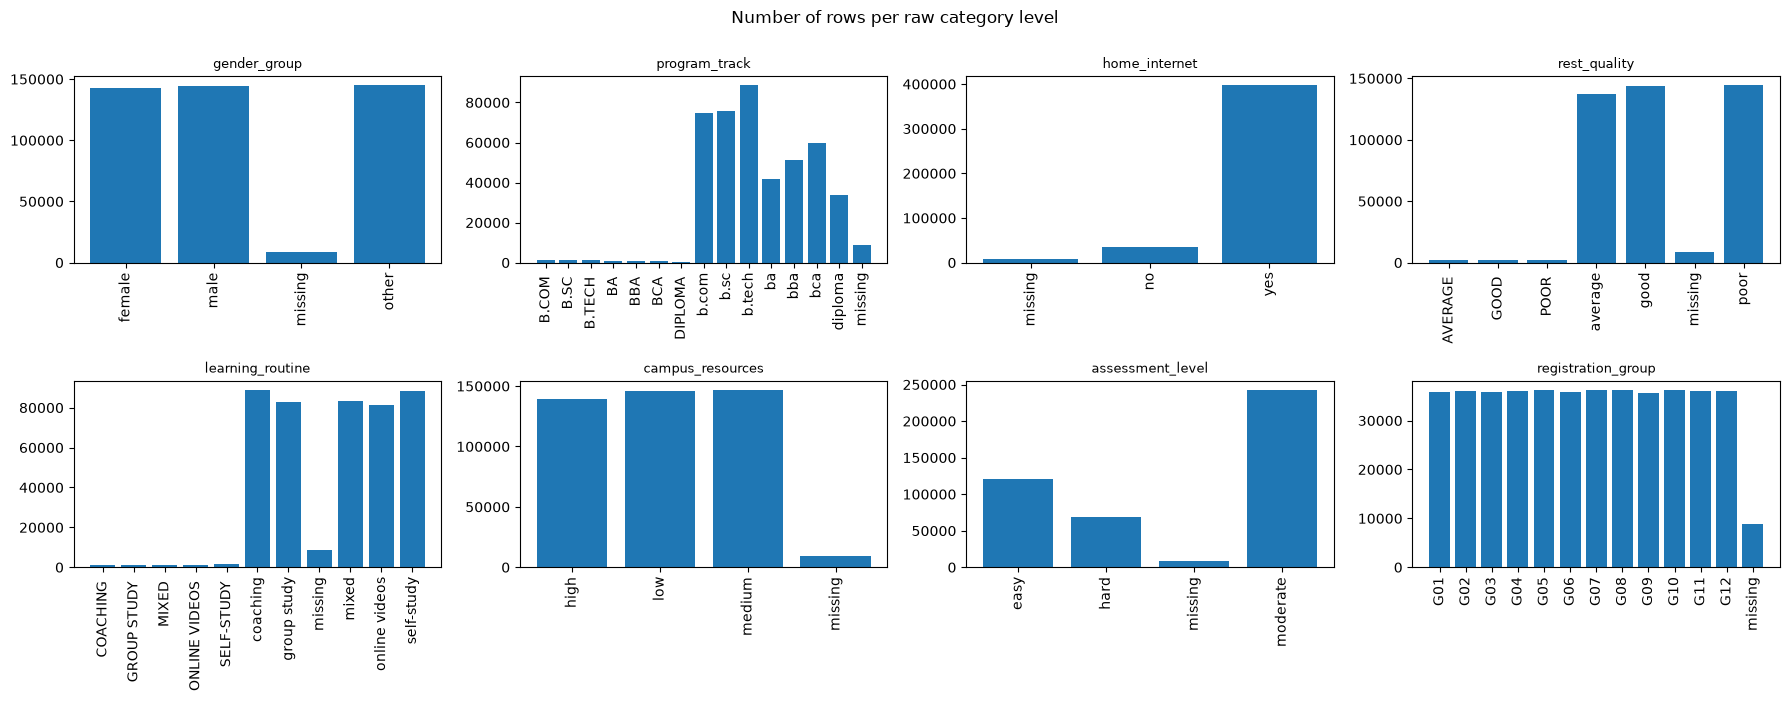

In [15]:
# Row counts per raw level
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), CAT_COLS):
    counts = train_df[col].fillna('missing').value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', rotation=90)
fig.suptitle('Number of rows per raw category level', y=1.0)
plt.tight_layout()
plt.show()

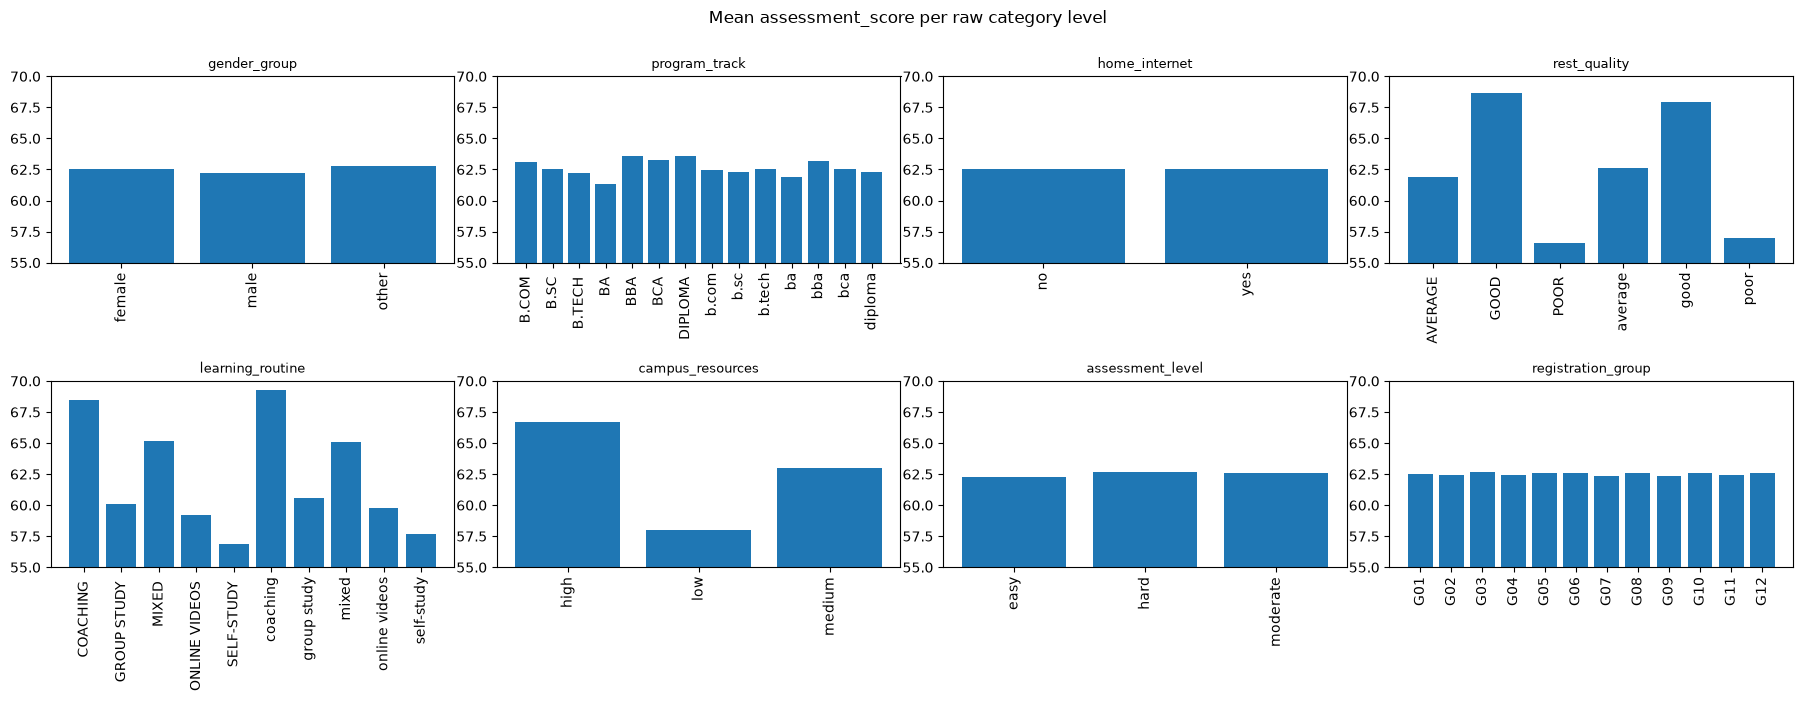

In [16]:
# Mean target per raw level (rows with missing values are excluded)
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), CAT_COLS):
    means = train_df.groupby(col)[TARGET].mean()
    ax.bar(means.index.astype(str), means.values)
    ax.set_title(col, fontsize=9)
    ax.set_ylim(55, 70)
    ax.tick_params(axis='x', rotation=90)
fig.suptitle('Mean assessment_score per raw category level', y=1.0)
plt.tight_layout()
plt.show()

<a id="sec-1-5"></a>
### 1.5 Numeric features: ranges and unusual values

In [17]:
train_df[NUM_COLS].describe(percentiles=[.01, .5, .99]).T.round(2)

,count,mean,std,min,1%,50%,99%,max
learner_age,427793.0,20.55,2.26,17.00,17.00,21.00,24.00,24.00
study_time,426806.0,4.04,2.51,0.00,0.05,4.01,7.95,32.24
attendance_rate,427780.0,72.10,17.58,38.70,40.80,72.60,99.80,150.00
sleep_duration,427822.0,7.07,1.75,3.85,4.07,7.10,9.93,10.18
study_minutes,427845.0,240.30,142.06,0.00,0.00,239.90,482.70,528.00
engagement_index,427648.0,64.32,16.28,16.41,30.12,64.49,97.43,110.87
intake_marker,427935.0,0.50,0.29,0.00,0.01,0.50,0.99,1.00


In [18]:
study_gap = train_df['study_minutes'] - 60 * train_df['study_time']
checks = {
    'attendance_rate > 100': (train_df['attendance_rate'] > 100).sum(),
    'study_time > 16 h (vs max(study_minutes) = 528 -> 8.8 h)': (train_df['study_time'] > 16).sum(),
    '|study_minutes - 60*study_time| > 60': (study_gap.abs() > 60).sum(),
}
pd.Series(checks, name='rows')

attendance_rate > 100                                        747
study_time > 16 h (vs max(study_minutes) = 528 -> 8.8 h)     657
|study_minutes - 60*study_time| > 60                        1223
Name: rows, dtype: int64

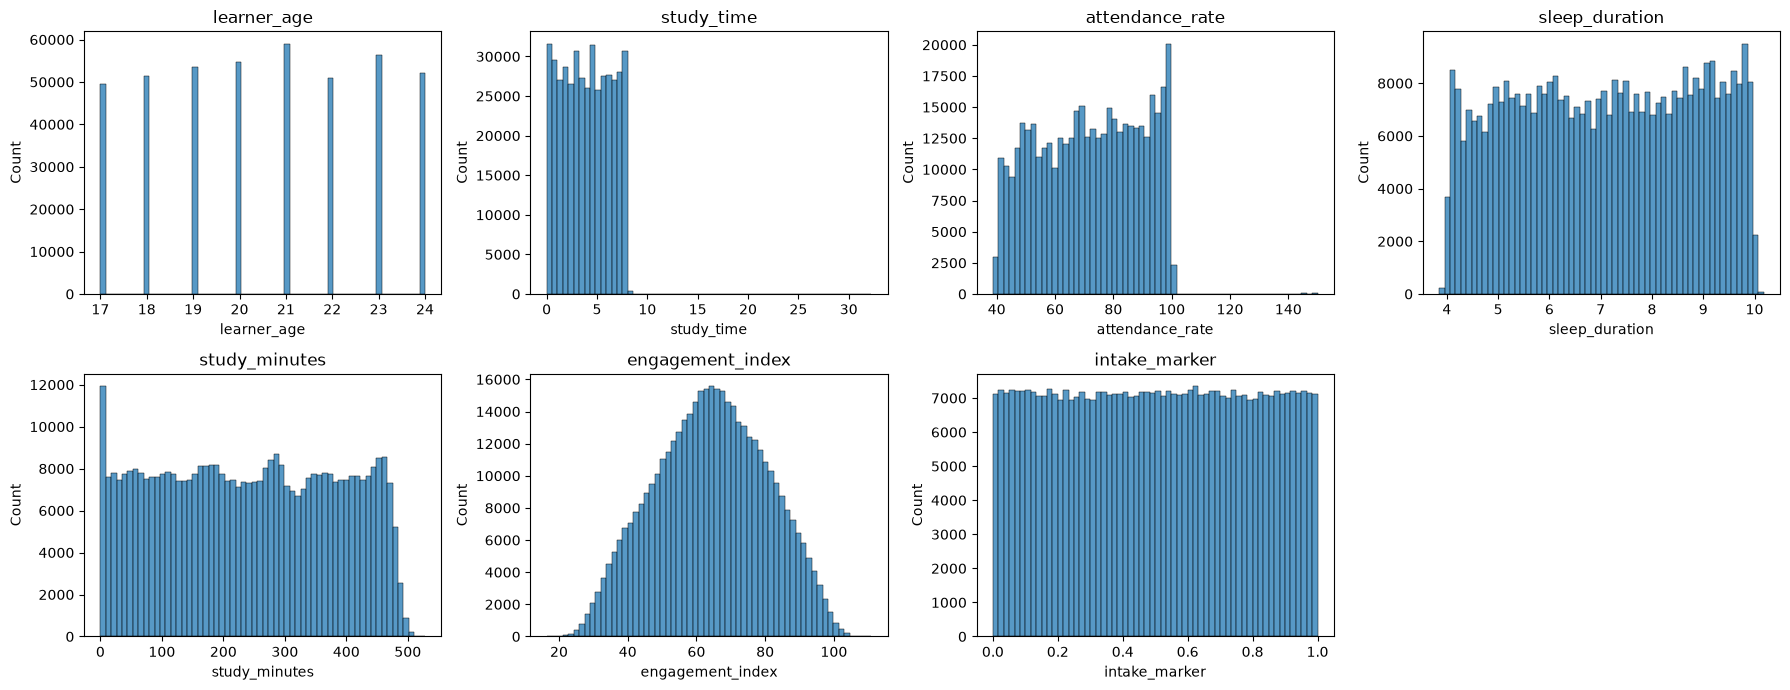

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), NUM_COLS):
    sns.histplot(train_df[c], bins=60, ax=ax)
    ax.set_title(c)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

<a id="sec-1-6"></a>
### 1.6 Relationship with the target and redundancy

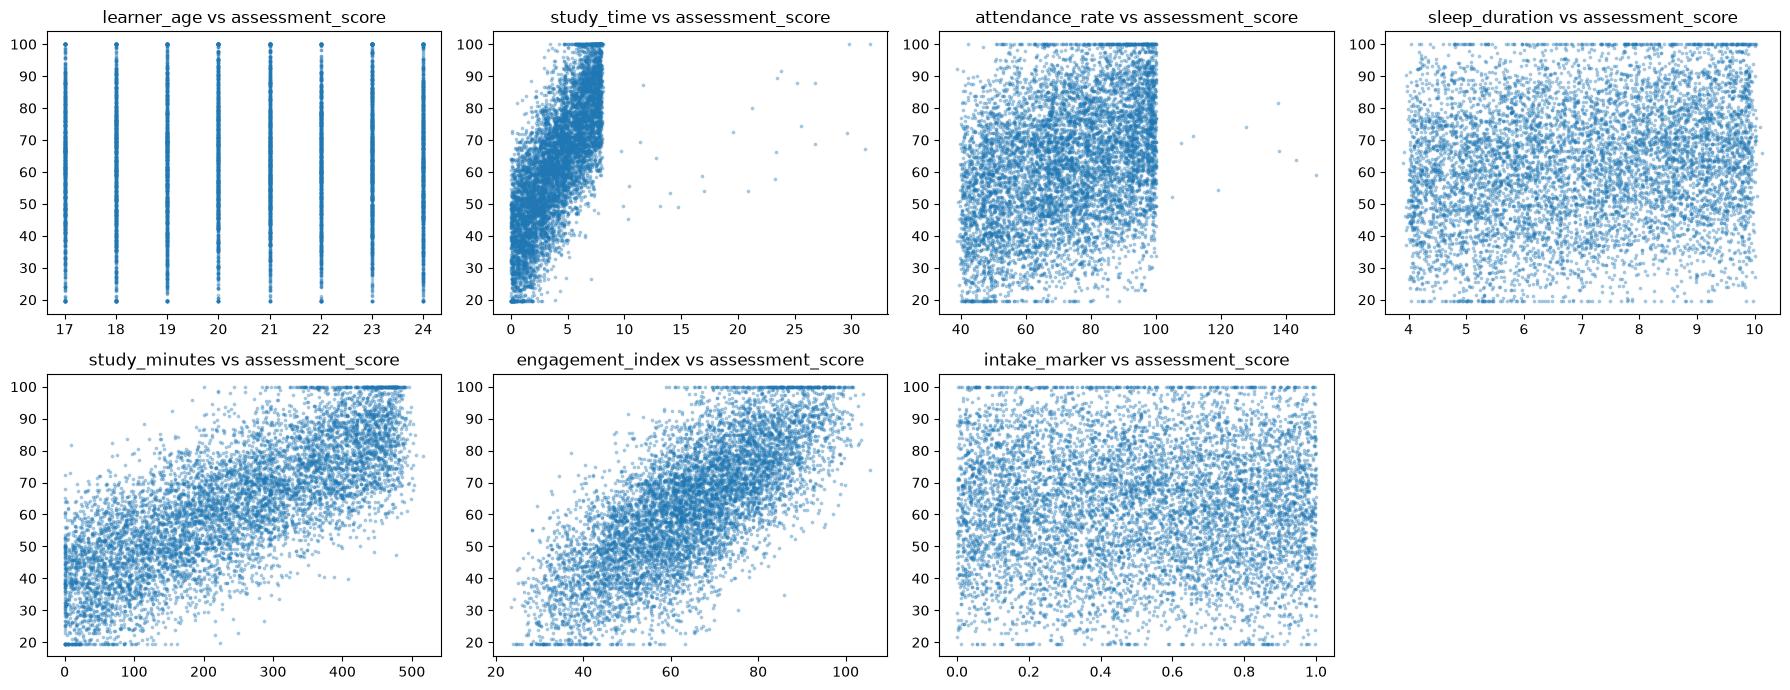

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
sample = train_df.sample(8000, random_state=RANDOM_SEED)
for ax, c in zip(axes.ravel(), NUM_COLS):
    ax.scatter(sample[c], sample[TARGET], s=3, alpha=0.3)
    ax.set_title(f'{c} vs {TARGET}')
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

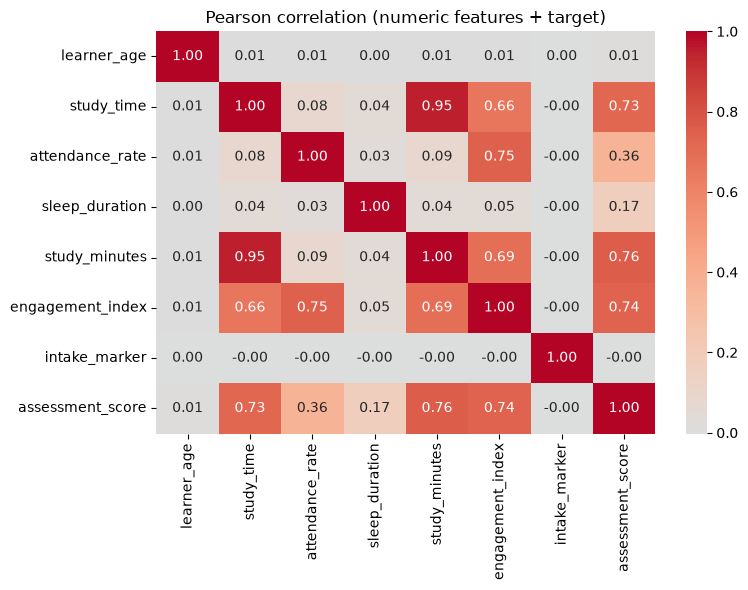

In [21]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = train_df[NUM_COLS + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pearson correlation (numeric features + target)')
plt.tight_layout()
plt.show()

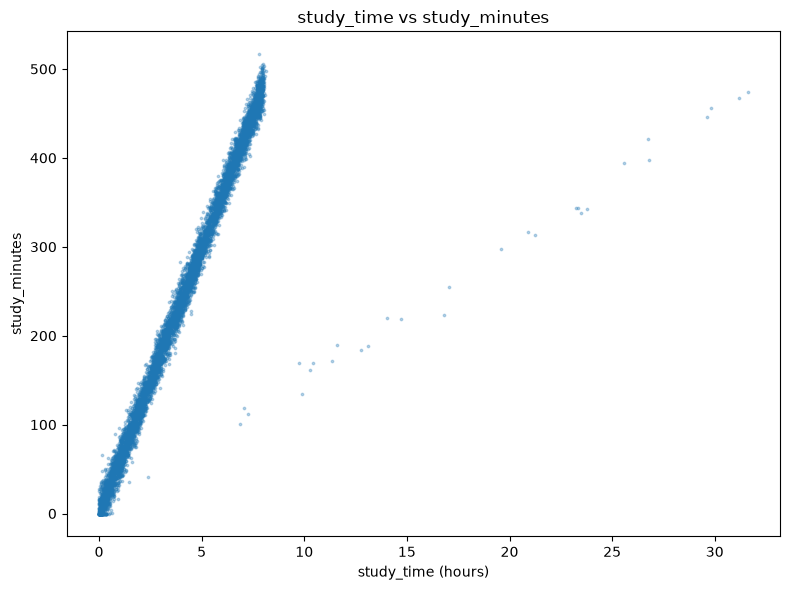

In [22]:
# Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(sample['study_time'], sample['study_minutes'], s=3, alpha=0.3)
plt.xlabel('study_time (hours)')
plt.ylabel('study_minutes')
plt.title('study_time vs study_minutes')
plt.tight_layout()
plt.show()

<a id="sec-1-7"></a>
### 1.7 Train / test / unlabeled distribution shift

In [23]:
shift = pd.DataFrame({name: df[NUM_COLS].mean() for name, df in
                      [('train', train_df), ('test', test_df), ('unlabeled', unlabeled_df)]})
shift['max |rel. diff| %'] = ((shift.max(axis=1) - shift.min(axis=1)) / shift['train'].abs() * 100).round(2)
display(shift.round(3))

# Largest difference in category shares between train and test
cat_shift = {}
for c in CAT_COLS:
    a = train_df[c].value_counts(normalize=True)
    b = test_df[c].value_counts(normalize=True)
    cat_shift[c] = a.sub(b, fill_value=0).abs().max()
pd.Series(cat_shift, name='max |share diff| train vs test').round(4)

,train,test,unlabeled,max |rel. diff| %
learner_age,20.547,20.543,20.542,0.02
study_time,4.040,4.038,4.040,0.06
attendance_rate,72.101,72.078,72.093,0.03
sleep_duration,7.071,7.075,7.071,0.06
study_minutes,240.302,240.019,240.385,0.15
engagement_index,64.318,64.269,64.306,0.08
intake_marker,0.500,0.501,0.500,0.20


gender_group          0.0014
program_track         0.0023
home_internet         0.0001
rest_quality          0.0011
learning_routine      0.0012
campus_resources      0.0008
assessment_level      0.0006
registration_group    0.0016
Name: max |share diff| train vs test, dtype: float64

<a id="sec-1-8"></a>
### 1.8 Preprocessing

All EDA above uses the raw data. Based on its findings, the preprocessing is split into two parts:

1. **Stateless cleaning** (rules that use no statistics of the data, so applying them before cross-validation cannot leak): normalise categorical text and clip implausible values. The result is stored in new frames `train_clean`, `test_clean` and `unlabeled_clean`; the raw frames stay untouched, and no rows are dropped.
2. **Learned preprocessing** (imputation, scaling, encoding): implemented as a scikit-learn pipeline that is fitted on the training part of each CV fold. The data frames are intentionally not imputed or scaled in advance: computing a median or mean on all rows would let the validation rows influence the training transformation (data leakage).

In [12]:
def clean_cat(s):
    """Normalise whitespace and casing of a categorical column."""
    return s.str.strip().str.lower()

def clean_categoricals(df):
    """Return a copy with all categorical columns formatted identically (stripped, lower-case)."""
    df = df.copy()
    for col in CAT_COLS:
        df[col] = clean_cat(df[col])
    return df

train_clean = clean_categoricals(train_df)
test_clean = clean_categoricals(test_df)
unlabeled_clean = clean_categoricals(unlabeled_df)

print("Categories after normalisation (train):")
for col in CAT_COLS:
    print(f"{col:20s} {sorted(train_clean[col].dropna().unique())}")

Categories after normalisation (train):
gender_group         ['female', 'male', 'other']
program_track        ['b.com', 'b.sc', 'b.tech', 'ba', 'bba', 'bca', 'diploma']
home_internet        ['no', 'yes']
rest_quality         ['average', 'good', 'poor']
learning_routine     ['coaching', 'group study', 'mixed', 'online videos', 'self-study']
campus_resources     ['high', 'low', 'medium']
assessment_level     ['easy', 'hard', 'moderate']
registration_group   ['g01', 'g02', 'g03', 'g04', 'g05', 'g06', 'g07', 'g08', 'g09', 'g10', 'g11', 'g12']


**Clipping.** `attendance_rate` is clipped to 100 and `study_time` to 16 h. The `study_time` clip is only a partial fix (see the conclusion).

In [13]:
CLIP_UPPER = {'attendance_rate': 100, 'study_time': 16}

def clip_invalid(df):
    """Return a copy with the implausible upper values clipped to the limits in CLIP_UPPER."""
    df = df.copy()
    for col, upper in CLIP_UPPER.items():
        df[col] = df[col].clip(upper=upper)
    return df

print("Values above the limit before clipping (train):",
      {col: int((train_clean[col] > up).sum()) for col, up in CLIP_UPPER.items()})

train_clean = clip_invalid(train_clean)
test_clean = clip_invalid(test_clean)
unlabeled_clean = clip_invalid(unlabeled_clean)

print("Values above the limit after clipping (train): ",
      {col: int((train_clean[col] > up).sum()) for col, up in CLIP_UPPER.items()})

train_clean[list(CLIP_UPPER)].agg(['min', 'max'])

Values above the limit before clipping (train): {'attendance_rate': 747, 'study_time': 657}
Values above the limit after clipping (train):  {'attendance_rate': 0, 'study_time': 0}


,attendance_rate,study_time
min,38.7,0.0
max,100.0,16.0


**Fold-safe pipeline.** The `preprocessor` below is added to every model through `create_pipeline`. It expects the cleaned frames (`train_clean`, `test_clean`), otherwise differently formatted levels (e.g. `' B.TECH '` and `'b.tech'`) would become separate one-hot columns. Models are trained on `train_clean[FEATURES]`.

In [14]:
# Fill missing numerical with Median, then Scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

# Fill missing categorical with "unknown", then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUM_COLS),
        ('cat', categorical_transformer, CAT_COLS)
    ],
    remainder='drop' # Drops any columns not in NUM_COLS or CAT_COLS
)

def create_pipeline(model):
    """
    Combines the global preprocessor and a given model into a single Scikit-Learn Pipeline.
    """
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])


In [15]:
X = train_clean[FEATURES]
y = train_clean[TARGET]

<a id="sec-1-9"></a>
### 1.9 EDA conclusion

**Dataset.** 441,000 labelled training rows, 189,000 test rows and 270,000 unlabelled rows, all with the same 15 features: 7 numeric and 8 categorical ([1.1](#sec-1-1)). The target `assessment_score` is a continuous score (0-100) with mean 62.5 and std 18.9 ([1.3](#sec-1-3)). `record_id` is an identifier and is never used as a feature.

**Main findings** (all computed on the raw data)

| Topic | Finding | Section |
|---|---|---|
| Missing values | About 3% per numeric and 2% per categorical column (31.5% of rows have at least one). Same rates in train, test and unlabeled; missingness is unrelated to the score. | [1.2](#sec-1-2) |
| Formatting | `program_track`, `rest_quality` and `learning_routine` contain padded and upper-case duplicates (14 → 7, 6 → 3 and 10 → 5 categories). | [1.4](#sec-1-4) |
| Invalid values | `attendance_rate` > 100 (747 rows, spread up to 150) and `study_time` > 16 h (657 rows, up to 32 h). | [1.5](#sec-1-5) |
| Redundancy | `study_time` and `study_minutes` are near copies of each other (Pearson r = 0.95). `engagement_index` also correlates with `attendance_rate` (0.75) and `study_time` (0.66), so it partly repeats them. | [1.6](#sec-1-6) |
| Signal | Strongest numeric predictors: `study_minutes` (r = 0.76), `engagement_index` (0.74), `study_time` (0.73), `attendance_rate` (0.36) and `sleep_duration` (0.17). `learning_routine`, `rest_quality` and `campus_resources` shift the mean score by 9-12 points between levels. `learner_age`, `intake_marker`, `home_internet` and `registration_group` look uninformative. | [1.4](#sec-1-4), [1.6](#sec-1-6) |
| Distribution shift | None: train, test and unlabeled agree to within 0.2% on means and category shares, so ordinary K-fold CV is representative. | [1.7](#sec-1-7) |

**Preprocessing applied** ([1.8](#sec-1-8))

| Step | Details |
|---|---|
| Normalise categorical text | `strip().lower()` on all 8 categorical columns of the train, test and unlabeled frames. |
| Clip implausible values | `attendance_rate` to 100 and `study_time` to 16. No rows are dropped. |
| Impute, scale, encode | Fold-safe `preprocessor` pipeline: median imputation and standard scaling for numeric columns, constant `unknown` and one-hot encoding for categorical columns. |

No features are dropped or created yet: the required baseline, tree, forest and XGBoost comparisons use the same basic features.

**Known issue: `study_time`.** The 657 values above 16 h average 24 h (max 32 h), while their `study_minutes` is normal (about 6 h), so `study_time` is corrupt there. The scatter plot of the two features in [1.6](#sec-1-6) shows the same outliers, so clipping to 16 h is only a partial fix. Both `study_time` and `study_minutes` are deliberately kept for the baseline models, as the assignment requires. The issue is handled properly in the *Your Pipeline - Feature Engineering* step at the end: `study_time` is dropped and only `study_minutes`, which has more plausible values, is kept, and the models are compared before and after the change.

**Candidates for feature engineering and later experiments**
- Drop weak features (`learner_age`, `intake_marker`, `home_internet`, `registration_group`) and check that the score does not get worse.
- Drop or merge the redundant `study_time` / `study_minutes` pair, and test dropping `engagement_index` or replacing it with interactions such as engagement × attendance (`engagement_index` and `attendance_rate` are correlated, r = 0.75).


<a id="sec-2"></a>
## 2. Baseline Models

This section contains baseline mean model and linear regression model.

### 2.1 Mean baseline

In [28]:
mean_baseline_pipeline = create_pipeline(DummyRegressor(strategy='mean'))

In [29]:
results['Mean baseline'] = evaluate_model(mean_baseline_pipeline, X, y, cv_splitter)

Evaluating Pipeline...
  Fold 1 RMSE: 18.9344
  Fold 2 RMSE: 18.8899
  Fold 3 RMSE: 18.9074
  Fold 4 RMSE: 18.9772
  Fold 5 RMSE: 18.8795
----------------------------------------
Mean Fold RMSE:   18.9177 ± 0.0351
Overall OOF RMSE: 18.9177
Mean train RMSE:  18.9177
----------------------------------------


### 2.2 Linear regression

In [30]:
linear_regression_pipeline = create_pipeline(LinearRegression())

In [31]:
results['Linear regression'] = evaluate_model(linear_regression_pipeline, X, y, cv_splitter)

Evaluating Pipeline...
  Fold 1 RMSE: 9.1828
  Fold 2 RMSE: 9.1526
  Fold 3 RMSE: 9.1617
  Fold 4 RMSE: 9.1634
  Fold 5 RMSE: 9.1636
----------------------------------------
Mean Fold RMSE:   9.1648 ± 0.0099
Overall OOF RMSE: 9.1648
Mean train RMSE:  9.1636
----------------------------------------


### 2.3 Comparison

In [32]:
baseline_table = results_table(results)
baseline_table['improvement vs mean baseline'] = (1 - baseline_table['OOF RMSE'] / baseline_table.loc['Mean baseline', 'OOF RMSE']).map('{:.1%}'.format)
baseline_table

,mean fold RMSE,std fold RMSE,OOF RMSE,train RMSE,improvement vs mean baseline
Mean baseline,18.9177,0.0351,18.9177,18.9177,0.0%
Linear regression,9.1648,0.0099,9.1648,9.1636,51.6%


The mean baseline reaches an RMSE of about 18.9, which is the standard deviation of the target. Linear regression halves the error to about 9.2 (a ~52% reduction), and the very small fold-to-fold standard deviation (about 0.01) shows that the result is stable across folds.

### 2.4 Coefficients and limitations

In [33]:
linear_regression_pipeline.fit(X, y)
coefs = pd.Series(linear_regression_pipeline[-1].coef_,
                  index=linear_regression_pipeline[0].get_feature_names_out()).rename(lambda n: n.split('__', 1)[1])

print(f"Intercept: {linear_regression_pipeline[-1].intercept_:.2f}  (mean target: {y.mean():.2f})")

all_coefs_df = pd.DataFrame(coefs, columns=['Coefficient']).sort_values(by='Coefficient', key=abs, ascending=False)

display(all_coefs_df.style.background_gradient(cmap='coolwarm', axis=0).format("{:.4f}"))

Intercept: 62.45  (mean target: 62.51)


,Coefficient
study_minutes,7.3299
learning_routine_coaching,5.8151
rest_quality_poor,-4.5027
rest_quality_good,4.4725
engagement_index,3.7925
study_time,3.7098
campus_resources_low,-3.6706
campus_resources_high,3.6659
learning_routine_self-study,-3.3895
attendance_rate,2.8088


**Interpretation of the intercept and coefficients:**

* **Intercept (62.45):** The predicted baseline score for a student whose numerical features are exactly average (scaled to 0). Because we one-hot encoded without dropping a baseline category, the model's solver forces the categorical coefficients to act as balanced positive and negative offsets (bonuses and penalties) that mathematically average out to zero. Consequently, the intercept absorbs the overall dataset baseline, placing it very close to the actual target mean (62.51).
* **Numeric Coefficients:** Because we used `StandardScaler`, these show the score change per one standard deviation increase in a feature (e.g., +1 std dev of `study_minutes` adds 7.33 points).
* **Categorical Coefficients:** The score shift of a specific category relative to the other levels of the same column (e.g., `coaching` adds 5.82; `poor` rest subtracts 4.50). Since all levels are one-hot encoded, only the differences between levels are meaningful.

As expected, features like `study_minutes`, `rest_quality`, and `learning_routine` have large absolute coefficients, indicating a strong impact on assessment scores. Conversely, the coefficients for `registration_group`, `home_internet`, and `program_track` are near zero. This suggests that these features have minimal predictive power and are candidates for removal, to be tested in the feature-engineering step.

**Linear regression Model Limitations:**
* **Multicollinearity:** Correlated features (like study time and minutes) make their individual coefficients unstable and unreliable, because the effect is split between them.
* **Ignores Boundaries:** Test scores have a strict 0–100 limit, but linear regression is an infinite line. It can predict impossible scores (like 110) and assumes constant linear returns, ignoring that the benefit of studying eventually diminishes.

<a id="sec-3"></a>
## 3. Regression Tree

### 3.1 Initial tree (default parameters)

In [43]:
regression_tree_pipeline = create_pipeline(DecisionTreeRegressor(random_state=RANDOM_SEED))
results['Decision tree (initial)'] = evaluate_model(regression_tree_pipeline, X, y, cv_splitter)

Evaluating Pipeline...
  Fold 1 RMSE: 13.0591
  Fold 2 RMSE: 13.0646
  Fold 3 RMSE: 13.0284
  Fold 4 RMSE: 13.0401
  Fold 5 RMSE: 13.0175
----------------------------------------
Mean Fold RMSE:   13.0419 ± 0.0178
Overall OOF RMSE: 13.0420
Mean train RMSE:  0.0000
----------------------------------------


### 3.2 Tuning the tree complexity

A grid search over two parameters on the same 5 folds, recording both the training and the validation RMSE of every configuration:
- `max_depth`: 3, 5, 7, 9, 11, 13, 15, unlimited (`None`)
- `min_samples_leaf`: 1, 10, 50, 100, 300

In [36]:
param_grid = {
    'model__max_depth': [3, 6, 9, 12, 15, 18, 21, None],
    'model__min_samples_leaf': [5, 10, 50, 100, 200, 300],
}

tree_search = GridSearchCV(
    create_pipeline(DecisionTreeRegressor(random_state=RANDOM_SEED)),
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv_splitter,
    return_train_score=True,
    n_jobs=-1,
)
tree_search.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 6, ...], 'model__min_samples_leaf': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit``

In [44]:
cv_res = pd.DataFrame(tree_search.cv_results_)
search_df = pd.DataFrame({
    'max_depth': cv_res['param_model__max_depth'].map(lambda d: 'None' if pd.isna(d) else str(int(d))),
    'min_samples_leaf': cv_res['param_model__min_samples_leaf'].astype(int),
    'train RMSE': -cv_res['mean_train_score'],
    'validation RMSE': -cv_res['mean_test_score'],
})
search_df['gap'] = search_df['validation RMSE'] - search_df['train RMSE']
depth_order = [str(d) for d in param_grid['model__max_depth']]

search_df.pivot(index='max_depth', columns='min_samples_leaf', values='validation RMSE').loc[depth_order].round(3)

min_samples_leaf,5,10,50,100,200,300
max_depth,,,,,,
3,11.936,11.936,11.936,11.936,11.936,11.936
6,10.572,10.572,10.572,10.572,10.572,10.572
9,9.806,9.805,9.804,9.804,9.813,9.825
12,9.587,9.559,9.487,9.485,9.535,9.593
15,10.064,9.873,9.463,9.436,9.512,9.585
18,10.796,10.285,9.476,9.435,9.512,9.585
21,11.215,10.436,9.476,9.435,9.512,9.585
None,11.395,10.469,9.476,9.435,9.512,9.585


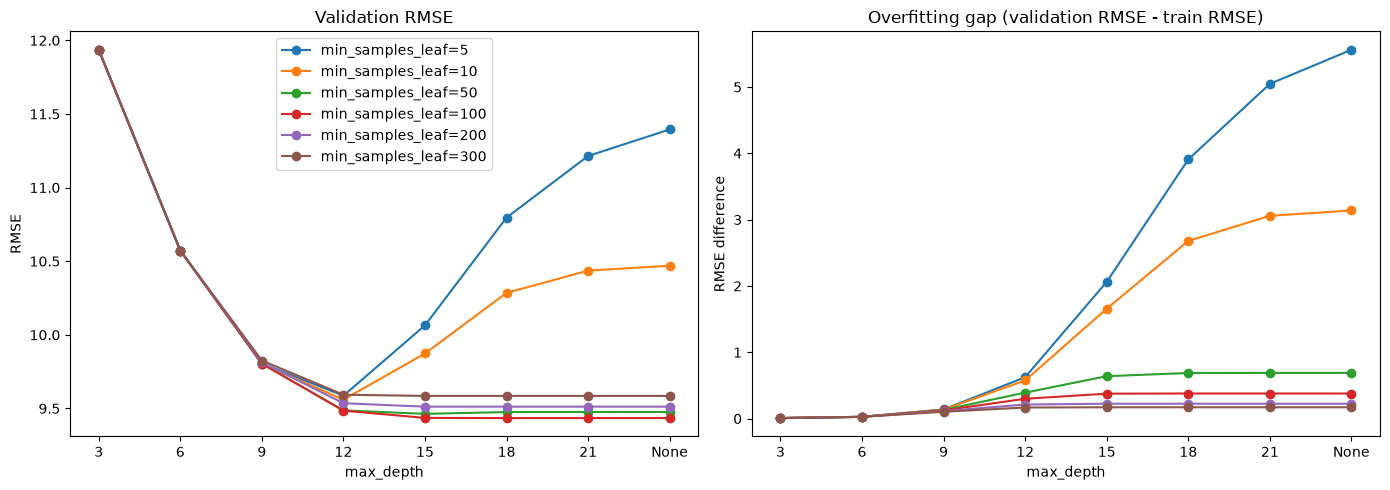

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for leaf, grp in search_df.groupby('min_samples_leaf'):
    grp = grp.set_index('max_depth').loc[depth_order]
    axes[0].plot(depth_order, grp['validation RMSE'], marker='o', label=f'min_samples_leaf={leaf}')
    axes[1].plot(depth_order, grp['gap'], marker='o', label=f'min_samples_leaf={leaf}')
axes[0].set(title='Validation RMSE', xlabel='max_depth', ylabel='RMSE')
axes[1].set(title='Overfitting gap (validation RMSE - train RMSE)', xlabel='max_depth', ylabel='RMSE difference')
axes[0].legend()
plt.tight_layout()
plt.show()

In [46]:
best_params = {name.replace('model__', ''): value for name, value in tree_search.best_params_.items()}
print("Selected parameters:", best_params)

search_df.sort_values('validation RMSE').head(5).round(3)

Selected parameters: {'max_depth': 18, 'min_samples_leaf': 100}


,max_depth,min_samples_leaf,train RMSE,validation RMSE,gap
39,21,100,9.056,9.435,0.378
45,None,100,9.056,9.435,0.378
33,18,100,9.056,9.435,0.378
27,15,100,9.060,9.436,0.376
26,15,50,8.823,9.463,0.640


### 3.3 Tuned tree and comparison

In [47]:
tuned_tree_pipeline = create_pipeline(DecisionTreeRegressor(random_state=RANDOM_SEED, **best_params))
results['Decision tree (tuned)'] = evaluate_model(tuned_tree_pipeline, X, y, cv_splitter)

Evaluating Pipeline...
  Fold 1 RMSE: 9.4566
  Fold 2 RMSE: 9.4302
  Fold 3 RMSE: 9.4238
  Fold 4 RMSE: 9.4274
  Fold 5 RMSE: 9.4350
----------------------------------------
Mean Fold RMSE:   9.4346 ± 0.0116
Overall OOF RMSE: 9.4346
Mean train RMSE:  9.0561
----------------------------------------


In [48]:
results_table(results)

,mean fold RMSE,std fold RMSE,OOF RMSE,train RMSE
Mean baseline,18.9177,0.0351,18.9177,18.9177
Linear regression,9.1648,0.0099,9.1648,9.1636
Decision tree (initial),13.0419,0.0178,13.0420,0.0000
Decision tree (tuned),9.4346,0.0116,9.4346,9.0561


**How the parameters affect over- and underfitting.**
- **`max_depth`:** a very shallow tree has too few splits to describe the data (underfitting: both train and validation RMSE are high). An unlimited tree keeps splitting until the leaves are almost pure, so it memorises the training rows (overfitting: the train RMSE is close to 0 while the validation RMSE is much higher).
- **`min_samples_leaf`:** forcing every leaf to contain many rows makes each prediction an average over many students, which smooths out noise and shrinks the train/validation gap. Too large a value prevents the tree from capturing real structure and causes underfitting.

<a id="sec-4"></a>
## 4. Random Forest

### 4.1 Initial forest

Default parameters (fully grown trees, all features at every split) with 50 trees. The number of trees is kept moderate for the initial run on purpose: fully grown trees are large (hundreds of thousands of leaves each), so memory use and training time grow quickly with `n_estimators`.

In [53]:
initial_random_forest = create_pipeline(RandomForestRegressor(n_estimators=50, random_state=RANDOM_SEED, n_jobs=-1))

results['Random forest (initial)']= evaluate_model(initial_random_forest, X, y, cv_splitter)

Evaluating Pipeline...
  Fold 1 RMSE: 9.2477
  Fold 2 RMSE: 9.2165
  Fold 3 RMSE: 9.2262
  Fold 4 RMSE: 9.2260
  Fold 5 RMSE: 9.2354
----------------------------------------
Mean Fold RMSE:   9.2304 ± 0.0105
Overall OOF RMSE: 9.2304
Mean train RMSE:  3.5112
----------------------------------------


### 4.2 Tuning the forest

A grid search over two parameters on the same 5 folds, recording train and validation RMSE:
- `max_features` (fraction of the features tried at each split): 0.33, 0.6, 1.0
- `min_samples_leaf`: 5, 20, 50. The single tree was best at around 50 to 100, but averaging makes a forest more tolerant of small leaves, so the grid is shifted lower.

To keep the search affordable, every configuration is fitted with 50 trees (`n_estimators` only reduces the variance of the average and is increased for the final model). The grid search itself runs sequentially and the parallelism is used inside each forest, so that two levels of parallelism do not compete for the CPU and memory.

In [ ]:
rf_param_grid = {
    'model__max_features': [0.33, 0.6, 0.8, 1.0],
    'model__min_samples_leaf': [10, 25, 50, 100],
}

rf_search = GridSearchCV(
    create_pipeline(RandomForestRegressor(n_estimators=50, random_state=RANDOM_SEED, n_jobs=8)),
    rf_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv_splitter,
    return_train_score=True,
    n_jobs=8,
)
rf_search.fit(X, y)

In [ ]:
rf_cv = pd.DataFrame(rf_search.cv_results_)
rf_search_df = pd.DataFrame({
    'max_features': rf_cv['param_model__max_features'].astype(float),
    'min_samples_leaf': rf_cv['param_model__min_samples_leaf'].astype(int),
    'train RMSE': -rf_cv['mean_train_score'],
    'validation RMSE': -rf_cv['mean_test_score'],
    'fit time per fold (s)': rf_cv['mean_fit_time'],
})
rf_search_df['gap'] = rf_search_df['validation RMSE'] - rf_search_df['train RMSE']

rf_search_df.sort_values('validation RMSE').round(3).reset_index(drop=True)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for max_features, grp in rf_search_df.groupby('max_features'):
    grp = grp.sort_values('min_samples_leaf')
    axes[0].plot(grp['min_samples_leaf'], grp['validation RMSE'], marker='o', label=f'max_features={max_features}')
    axes[1].plot(grp['min_samples_leaf'], grp['gap'], marker='o', label=f'max_features={max_features}')
axes[0].set(title='Validation RMSE', xlabel='min_samples_leaf', ylabel='RMSE')
axes[1].set(title='Overfitting gap (validation RMSE - train RMSE)', xlabel='min_samples_leaf', ylabel='RMSE difference')
axes[0].legend()
plt.tight_layout()
plt.show()

In [ ]:
best_rf_params = {name.replace('model__', ''): value for name, value in rf_search.best_params_.items()}
print("Selected parameters:", best_rf_params)

### 4.3 Tuned forest and comparison

The selected parameters are used to train the final forest with 200 trees (more trees only reduce the variance of the average, at a linear cost in time). It is evaluated on the same folds as all previous models.

In [ ]:
tuned_rf_pipeline = create_pipeline(
    RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1, **best_rf_params))

results['Random forest (tuned)'] = evaluate_model(tuned_rf_pipeline, X, y, cv_splitter)

In [ ]:
results_table(results)

**Forest vs single tree.**
- **Variance reduction:** one tree fitted to bootstrap samples is unstable, but the average of many such trees is much more stable. That is why a forest can use deep, low-bias trees and still generalise: the individual overfitting errors are largely independent and cancel in the average.
- **`max_features`:** a smaller fraction forces the trees to use different features, which decorrelates them and makes averaging more effective. Too small a fraction makes every tree weak, because it often cannot see the strongest features.
- **`min_samples_leaf`:** limits how closely each tree follows noise. The forest tolerates smaller leaves than a single tree, because the remaining noise is averaged out.
- **`n_estimators`:** more trees reduce the variance of the average with diminishing returns, and unlike tree depth they do not cause overfitting; they only cost time. The forest is therefore several times (about `n_estimators` times) slower to train than a single tree, which is visible in the `fit time (s)` column.

The tuned parameters were selected on the same 5 folds that are reported, so the tuned-forest score is a development estimate.

*The observed values, the selected parameters, the training-time comparison and the comparison with the tuned tree and the linear baseline are discussed after the cells above have been run. To get the training time of the earlier models, re-run their `evaluate_model` cells once.*